# 04. Entrenamiento — EfficientNet-B0

Modelo timm: `efficientnet_b0` | Input 128×128 | Transfer learning

## 1. Configuración

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import create_dataloaders
from src.models.train import train_model
from src.utils.helpers import get_device, set_seed

MODEL_NAME = "efficientnet_b0"
MODEL_LABEL = "EfficientNet-B0"

DATA_DIR = ROOT / "data"
MODELS_DIR = DATA_DIR / "06_models"

BATCH_SIZE = 128
NUM_WORKERS = 8
MAX_EPOCHS = 25
PATIENCE = 4
LR = 1e-4
SEED = 42

set_seed(SEED)
device = get_device()
print(f"Modelo: {MODEL_LABEL} ({MODEL_NAME})")
print(f"Device: {device}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo: EfficientNet-B0 (efficientnet_b0)
Device: privateuseone:0


## 2. DataLoaders

In [2]:
loaders = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

print(f"Train: {len(train_loader.dataset):,} chips")
print(f"Val:   {len(val_loader.dataset):,} chips")
print(f"Test:  {len(test_loader.dataset):,} chips (usar solo en notebook 05)")

Train: 81,938 chips
Val:   14,840 chips
Test:  14,806 chips (usar solo en notebook 05)


## 3. Entrenamiento

In [3]:
summary = train_model(
    model_name=MODEL_NAME,
    train_loader=train_loader,
    val_loader=val_loader,
    save_dir=MODELS_DIR,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    lr=LR,
)

print(f"\nMejor epoch: {summary['best_epoch']}")
print(f"Mejor val macro F1: {summary['best_val_macro_f1']:.4f}")

Entrenando efficientnet_b0 en privateuseone:0
Train: 81,938 | Val: 14,840


train:   0%|          | 0/641 [00:00<?, ?it/s]c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch 01/25 | train loss 0.9881 acc 0.666 | val loss 0.6190 acc 0.658 F1 0.658 (com recall 0.705) | 389s
  → Mejor modelo guardado (macro F1 = 0.6578)


Epoch 02/25 | train loss 0.5429 acc 0.729 | val loss 0.5943 acc 0.669 F1 0.667 (com recall 0.832) | 346s
  → Mejor modelo guardado (macro F1 = 0.6669)


Epoch 03/25 | train loss 0.5183 acc 0.742 | val loss 0.5605 acc 0.705 F1 0.705 (com recall 0.756) | 337s
  → Mejor modelo guardado (macro F1 = 0.7051)


...

Epoch 08/25 | train loss 0.4552 acc 0.776 | val loss 0.4896 acc 0.755 F1 0.755 (com recall 0.785) | 337s
  → Mejor modelo guardado (macro F1 = 0.7550)


Epoch 09/25 | train loss 0.4470 acc 0.782 | val loss 0.5307 acc 0.718 F1 0.717 (com recall 0.860) | 336s


Epoch 10/25 | train loss 0.4425 acc 0.784 | val loss 0.5543 acc 0.703 F1 0.700 (com recall 0.900) | 336s


Epoch 11/25 | train loss 0.4344 acc 0.789 | val loss 0.4987 acc 0.746 F1 0.746 (com recall 0.811) | 337s


Epoch 12/25 | train loss 0.4327 acc 0.793 | val loss 0.5190 acc 0.741 F1 0.741 (com recall 0.839) | 336s
Early stopping en epoch 12 (sin mejora en 4 epochs)

Listo. Mejor epoch: 8 | val macro F1: 0.7550
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\efficientnet_b0_best.pt

Mejor epoch: 8
Mejor val macro F1: 0.7550


## 4. Curvas de entrenamiento

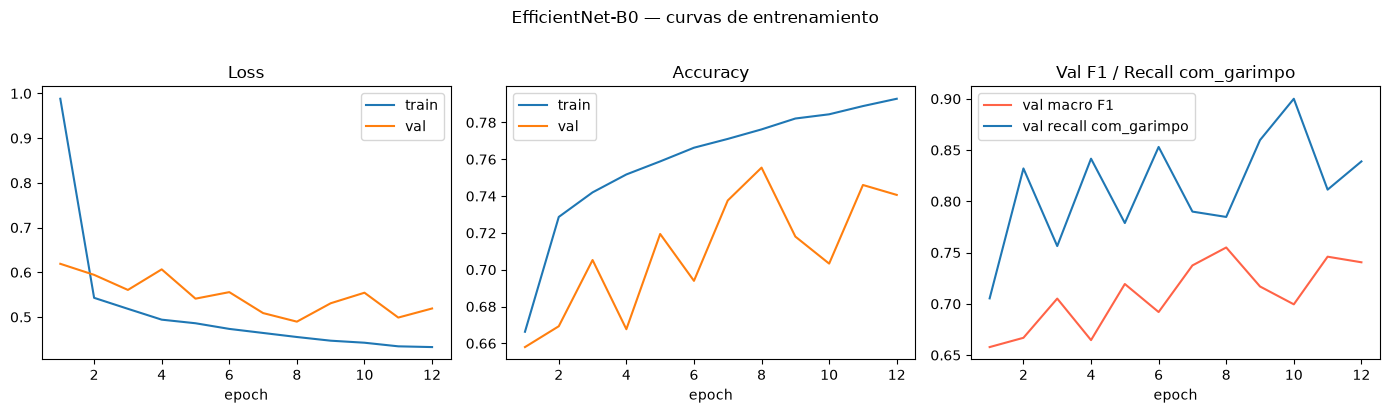

Figura guardada: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\reports\figures\efficientnet_b0_training_curves.png


In [4]:
history = summary["history"]
epochs = [r["epoch"] for r in history["train"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs, [r["loss"] for r in history["train"]], label="train")
axes[0].plot(epochs, [r["loss"] for r in history["val"]], label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("epoch")

axes[1].plot(epochs, [r["accuracy"] for r in history["train"]], label="train")
axes[1].plot(epochs, [r["accuracy"] for r in history["val"]], label="val")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("epoch")

axes[2].plot(epochs, [r["macro_f1"] for r in history["val"]], label="val macro F1", color="tomato")
axes[2].plot(epochs, [r["recall_com_garimpo"] for r in history["val"]], label="val recall com_garimpo")
axes[2].set_title("Val F1 / Recall com_garimpo"); axes[2].legend(); axes[2].set_xlabel("epoch")

plt.suptitle(f"{MODEL_LABEL} — curvas de entrenamiento", y=1.02)
plt.tight_layout()
fig_path = ROOT / "reports" / "figures" / f"{MODEL_NAME}_training_curves.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path}")

## 5. Resultado

Checkpoint en `data/06_models/efficientnet_b0_best.pt`. Evalúa en test desde `05_evaluation.ipynb`.